# Job Recommendation System
## Step 5: Convert Text to Features — TF-IDF Analysis & Word Embeddings

**Internship Project** | Gamage Recruiters
**Focus:** Recruitment & HR / Data Science & Machine Learning

---

In Step 3 we built TF-IDF vectors and used them directly for cosine similarity in Step 4.
In this step we go deeper — analysing **what the TF-IDF model actually learned**, and then building a second feature representation using **Word2Vec embeddings** to compare both approaches.

| Section | What we do |
|---|---|
| **TF-IDF Analysis** | Vocabulary stats, top terms per domain, feature importance heatmap |
| **Score Distribution** | How similarity scores are spread across all candidate-job pairs |
| **Word2Vec Embeddings** | Train a Word2Vec model on skill tokens, generate 100-dim vectors |
| **Comparison** | Correlation between TF-IDF and W2V similarity scores |
| **Verdict** | When to use TF-IDF vs Word2Vec in a recommendation system |

## 1. Install & Import Libraries

In [1]:
import sys
print(sys.executable)

F:\physical science\4th year\Internship\Task 16\job-recommendation-system\gensim_env\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import re
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# Plot style
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'sans-serif'})

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Artifacts from Steps 2–4

In [4]:
df_c = pd.read_csv('../data/candidates_preprocessed.csv')
df_j = pd.read_csv('../data/job_postings_preprocessed.csv')

candidate_tfidf = sp.load_npz('../models/candidate_tfidf_matrix.npz')
job_tfidf       = sp.load_npz('../models/job_tfidf_matrix.npz')

with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('../models/encoders.pkl', 'rb') as f:
    encoders = pickle.load(f)

feature_names = tfidf.get_feature_names_out()
domains       = sorted(df_c['primary_domain'].unique())

print(f'Candidates         : {df_c.shape}')
print(f'Job Postings       : {df_j.shape}')
print(f'Candidate TF-IDF   : {candidate_tfidf.shape}')
print(f'Job TF-IDF         : {job_tfidf.shape}')
print(f'Vocabulary size    : {len(tfidf.vocabulary_)} tokens')
print(f'Domains            : {domains}')

Candidates         : (500, 22)
Job Postings       : (200, 26)
Candidate TF-IDF   : (500, 300)
Job TF-IDF         : (200, 300)
Vocabulary size    : 300 tokens
Domains            : ['Finance', 'HR', 'Marketing', 'Operations', 'Technology']


## 3. TF-IDF Vocabulary Analysis

The vectorizer built a shared vocabulary of 300 tokens from candidate summaries and job descriptions.
Here we explore what's in it and which tokens are most informative per domain.

In [5]:
# Overall vocabulary stats
print('=== TF-IDF Vocabulary Stats ===')
print(f'Total tokens (features) : {len(tfidf.vocabulary_)}')
print(f'N-gram range            : {tfidf.ngram_range}')
print(f'Max features            : {tfidf.max_features}')
print(f'Min document frequency  : {tfidf.min_df}')
print()

# Separate single tokens from bi-grams
unigrams = [t for t in tfidf.vocabulary_ if '_' not in t and ' ' not in t]
bigrams  = [t for t in tfidf.vocabulary_ if '_' in t or ' ' in t]
print(f'Unigrams (single words) : {len(unigrams)}')
print(f'Bi-grams (skill phrases): {len(bigrams)}')
print()
print('Sample skill bi-grams in vocabulary:')
print([t for t in bigrams if any(c.isalpha() for c in t)][:20])

=== TF-IDF Vocabulary Stats ===
Total tokens (features) : 300
N-gram range            : (1, 2)
Max features            : 300
Min document frequency  : 2

Unigrams (single words) : 175
Bi-grams (skill phrases): 125

Sample skill bi-grams in vocabulary:
['scikit learn', 'tax_planning', 'attention_to_detail', 'financial_modeling', 'portfolio_management', 'equity_research', 'analytical_thinking', 'risk_analysis', 'tax planning', 'university moratuwa', 'vendor_management', 'risk_management', 'six_sigma', 'project_management', 'vendor management', 'university contract', 'data_analysis', 'data_analysis excel', 'data analysis', 'wayamba university']


## 4. Top TF-IDF Terms Per Domain

In [6]:
domain_top_terms = {}
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for domain in domains:
    idx    = df_c[df_c['primary_domain'] == domain].index
    scores = np.asarray(candidate_tfidf[idx].mean(axis=0)).flatten()
    top10  = pd.Series(scores, index=feature_names).sort_values(ascending=False).head(10)
    domain_top_terms[domain] = top10
    print(f'[{domain}] Top 10 terms:')
    for term, score in top10.items():
        print(f'  {term:<35} {score:.4f}')
    print()

[Finance] Top 10 terms:
  finance                             0.1276
  gaap                                0.1076
  equity_research                     0.1030
  fixed_income                        0.0979
  tax_planning                        0.0958
  risk_analysis                       0.0904
  analytical_thinking                 0.0903
  accounting                          0.0877
  power_bi                            0.0871
  bloomberg_terminal                  0.0861

[HR] Top 10 terms:
  hr                                  0.1457
  onboarding                          0.1302
  organizational_skills               0.1267
  hris                                0.1223
  recruitment                         0.1203
  labor_law                           0.1148
  succession_planning                 0.1134
  employee_relations                  0.1127
  _development                        0.1121
  training_ _development              0.1121

[Marketing] Top 10 terms:
  marketing                  

### Plot — Top TF-IDF Terms by Domain

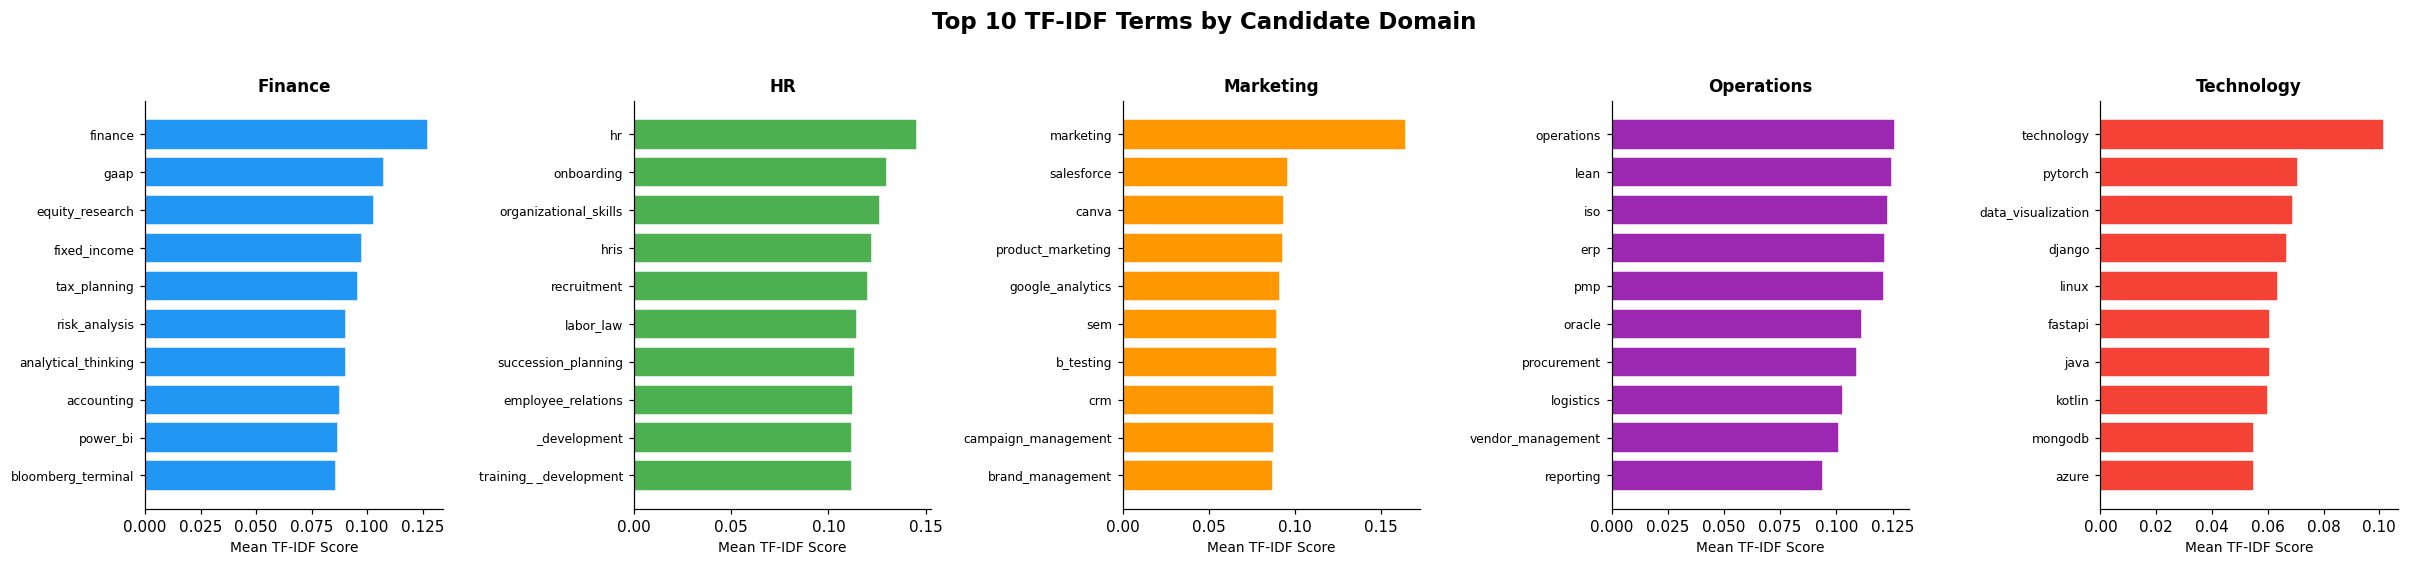

Each bar chart shows the most distinguishing skill tokens for that domain.


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Top 10 TF-IDF Terms by Candidate Domain', fontsize=15, fontweight='bold', y=1.02)

for ax, domain, color in zip(axes, domains, colors):
    top10 = domain_top_terms[domain]
    ax.barh(top10.index[::-1], top10.values[::-1], color=color, edgecolor='white')
    ax.set_title(domain, fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean TF-IDF Score', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot1_tfidf_by_domain.png', bbox_inches='tight')
plt.show()
print('Each bar chart shows the most distinguishing skill tokens for that domain.')

### Plot — Feature Importance Heatmap

Which skill tokens appear strongly across multiple domains?
High values in multiple rows = a cross-domain skill (e.g. Excel, SQL).
High value in only one row = a domain-specific signal (e.g. GAAP for Finance).

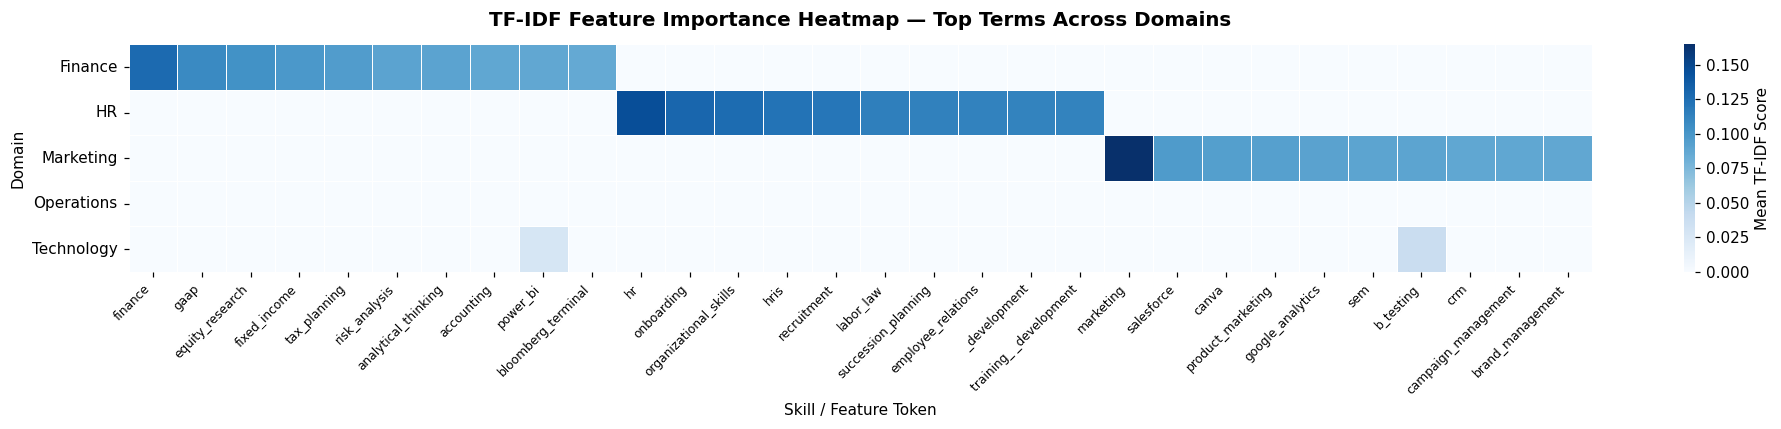

Dark blue = high TF-IDF weight for that domain. Light = low or absent.


In [8]:
# Collect top-10 terms per domain, de-duplicated
all_top_terms = list(dict.fromkeys(
    t for terms in domain_top_terms.values() for t in terms.index
))[:30]

# Build (domains x terms) matrix
heatmap_data = pd.DataFrame(index=domains, columns=all_top_terms, dtype=float)
for domain in domains:
    idx    = df_c[df_c['primary_domain'] == domain].index
    scores = np.asarray(candidate_tfidf[idx].mean(axis=0)).flatten()
    for term in all_top_terms:
        if term in feature_names:
            pos = list(feature_names).index(term)
            heatmap_data.loc[domain, term] = scores[pos]

heatmap_data = heatmap_data.fillna(0).astype(float)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Mean TF-IDF Score'}, annot=False)
ax.set_title('TF-IDF Feature Importance Heatmap — Top Terms Across Domains',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Skill / Feature Token', fontsize=10)
ax.set_ylabel('Domain', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/plot2_feature_heatmap.png', bbox_inches='tight')
plt.show()
print('Dark blue = high TF-IDF weight for that domain. Light = low or absent.')

## 5. TF-IDF Cosine Similarity Score Distribution

In [9]:
tfidf_sim = cosine_similarity(candidate_tfidf, job_tfidf)   # (500, 200)

print('TF-IDF cosine similarity stats (all 100,000 pairs):')
flat = tfidf_sim.flatten()
print(f'  Min    : {flat.min():.4f}')
print(f'  Max    : {flat.max():.4f}')
print(f'  Mean   : {flat.mean():.4f}')
print(f'  Median : {np.median(flat):.4f}')
print(f'  Std    : {flat.std():.4f}')
print()

# Top-1 score per candidate
top1_scores = [tfidf_sim[i].max() for i in range(len(df_c))]
print(f'Top-1 score per candidate:')
print(f'  Min  : {min(top1_scores):.4f}')
print(f'  Max  : {max(top1_scores):.4f}')
print(f'  Mean : {np.mean(top1_scores):.4f}')

TF-IDF cosine similarity stats (all 100,000 pairs):
  Min    : 0.0000
  Max    : 0.7578
  Mean   : 0.0716
  Median : 0.0273
  Std    : 0.1105

Top-1 score per candidate:
  Min  : 0.2364
  Max  : 0.7578
  Mean : 0.4942


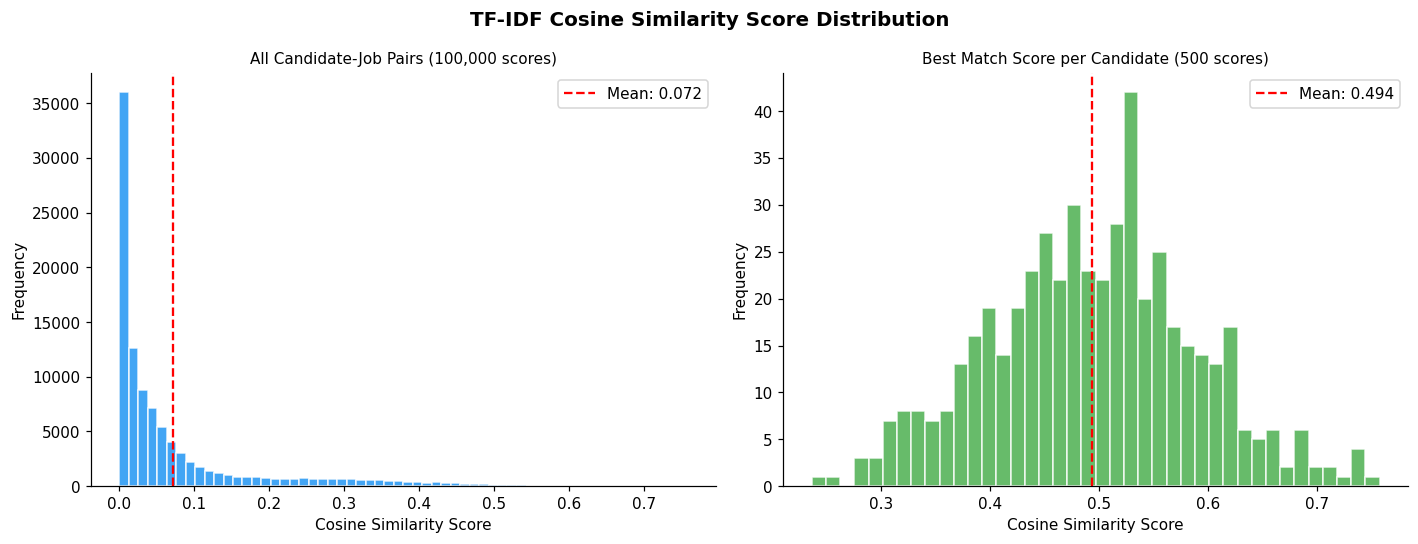

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('TF-IDF Cosine Similarity Score Distribution', fontsize=13, fontweight='bold')

axes[0].hist(flat, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('All Candidate-Job Pairs (100,000 scores)', fontsize=10)
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(flat.mean(), color='red', linestyle='--', label=f'Mean: {flat.mean():.3f}')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(top1_scores, bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Best Match Score per Candidate (500 scores)', fontsize=10)
axes[1].set_xlabel('Cosine Similarity Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(top1_scores), color='red', linestyle='--',
                label=f'Mean: {np.mean(top1_scores):.3f}')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot3_tfidf_distribution.png', bbox_inches='tight')
plt.show()

## 6. Word2Vec Skill Embeddings

TF-IDF treats each skill as an independent token — it has no concept of semantic similarity.
**Word2Vec** learns dense vector representations where similar skills end up close in vector space
(e.g. *PyTorch* and *TensorFlow* should be nearby).

### How it works
- Each skill token is a "word" in the Word2Vec vocabulary
- The model trains on sequences of skills co-occurring in the same candidate/job profile
- Output: a 100-dimensional vector per skill
- Candidate/job representation = **mean of all their skill vectors**

### 6a. Tokenise Skills

In [11]:
def tokenize_skills(skill_str):
    """
    Convert a comma-separated skill string into a list of underscore-joined tokens.
    e.g. 'Machine Learning, SQL, Power BI' -> ['machine_learning', 'sql', 'power_bi']
    """
    if pd.isna(skill_str):
        return []
    return [re.sub(r'\s+', '_', s.strip().lower())
            for s in str(skill_str).split(',') if s.strip()]

# Build corpus: each candidate/job is a sentence of skill tokens
cand_skill_tokens = df_c['skills'].apply(tokenize_skills).tolist()
job_skill_tokens  = df_j['required_skills'].apply(tokenize_skills).tolist()
all_sentences     = cand_skill_tokens + job_skill_tokens

print(f'Total sentences for Word2Vec training : {len(all_sentences)}')
print(f'Sample candidate tokens : {cand_skill_tokens[0]}')
print(f'Sample job tokens       : {job_skill_tokens[0]}')

Total sentences for Word2Vec training : 700
Sample candidate tokens : ['mongodb', 'scikit-learn', 'pytorch', 'tensorflow']
Sample job tokens       : ['teamwork', 'financial_modeling', 'tax_planning', 'tableau', 'accounting', 'python', 'fixed_income', 'presentation_skills', 'power_bi']


### 6b. Train Word2Vec Model

In [12]:
w2v_model = Word2Vec(
    sentences    = all_sentences,
    vector_size  = 100,    # 100-dimensional embedding per skill
    window       = 5,      # context window size
    min_count    = 1,      # include all skills regardless of frequency
    workers      = 2,
    seed         = 42,
    epochs       = 50
)

print(f'Word2Vec training complete')
print(f'Vocabulary size  : {len(w2v_model.wv)} unique skill tokens')
print(f'Vector dimension : {w2v_model.vector_size}')
print()
print('Skills most similar to python:')
for skill, score in w2v_model.wv.most_similar('python', topn=7):
    print(f'  {skill:<30} similarity: {score:.4f}')
print()
print('Skills most similar to financial_modeling:')
for skill, score in w2v_model.wv.most_similar('financial_modeling', topn=7):
    print(f'  {skill:<30} similarity: {score:.4f}')

Word2Vec training complete
Vocabulary size  : 129 unique skill tokens
Vector dimension : 100

Skills most similar to python:
  tableau                        similarity: 0.9965
  statistics                     similarity: 0.9897
  r                              similarity: 0.9847
  power_bi                       similarity: 0.9803
  agile                          similarity: 0.8607
  accounting                     similarity: 0.8435
  auditing                       similarity: 0.8363

Skills most similar to financial_modeling:
  derivatives                    similarity: 0.9991
  ifrs                           similarity: 0.9983
  investment_analysis            similarity: 0.9981
  vba                            similarity: 0.9980
  bloomberg_terminal             similarity: 0.9976
  fixed_income                   similarity: 0.9976
  tax_planning                   similarity: 0.9973


### 6c. Generate Candidate & Job Embeddings

In [13]:
def get_mean_embedding(tokens, model):
    """
    Return the mean Word2Vec vector for a list of skill tokens.
    Skills not in the vocabulary are ignored.
    Falls back to a zero vector if none of the tokens are in the vocab.
    """
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Generate (500, 100) and (200, 100) embedding matrices
cand_embeddings = np.array([
    get_mean_embedding(tokenize_skills(s), w2v_model) for s in df_c['skills']
])
job_embeddings = np.array([
    get_mean_embedding(tokenize_skills(s), w2v_model) for s in df_j['required_skills']
])

print(f'Candidate embedding matrix : {cand_embeddings.shape}')
print(f'Job embedding matrix       : {job_embeddings.shape}')
print()
print(f'Sample candidate embedding (first 10 dims):')
print(np.round(cand_embeddings[0, :10], 4))

Candidate embedding matrix : (500, 100)
Job embedding matrix       : (200, 100)

Sample candidate embedding (first 10 dims):
[ 0.2532 -0.1841 -0.2688 -0.1566 -0.1939 -0.3087  0.3097 -0.2181 -0.5139
 -0.3682]


### 6d. Compute Word2Vec Cosine Similarity

In [14]:
w2v_sim = cosine_similarity(cand_embeddings, job_embeddings)   # (500, 200)

print('Word2Vec cosine similarity stats:')
w2v_flat = w2v_sim.flatten()
print(f'  Min    : {w2v_flat.min():.4f}')
print(f'  Max    : {w2v_flat.max():.4f}')
print(f'  Mean   : {w2v_flat.mean():.4f}')
print(f'  Median : {np.median(w2v_flat):.4f}')
print(f'  Std    : {w2v_flat.std():.4f}')
print()
print('Compare to TF-IDF:')
print(f'  TF-IDF mean : {flat.mean():.4f}  (sparse — many near-zero scores)')
print(f'  W2V mean    : {w2v_flat.mean():.4f}  (denser — embeddings generalise better)')

Word2Vec cosine similarity stats:
  Min    : 0.1061
  Max    : 1.0000
  Mean   : 0.4988
  Median : 0.4025
  Std    : 0.2630

Compare to TF-IDF:
  TF-IDF mean : 0.0716  (sparse — many near-zero scores)
  W2V mean    : 0.4988  (denser — embeddings generalise better)


## 7. TF-IDF vs Word2Vec Comparison

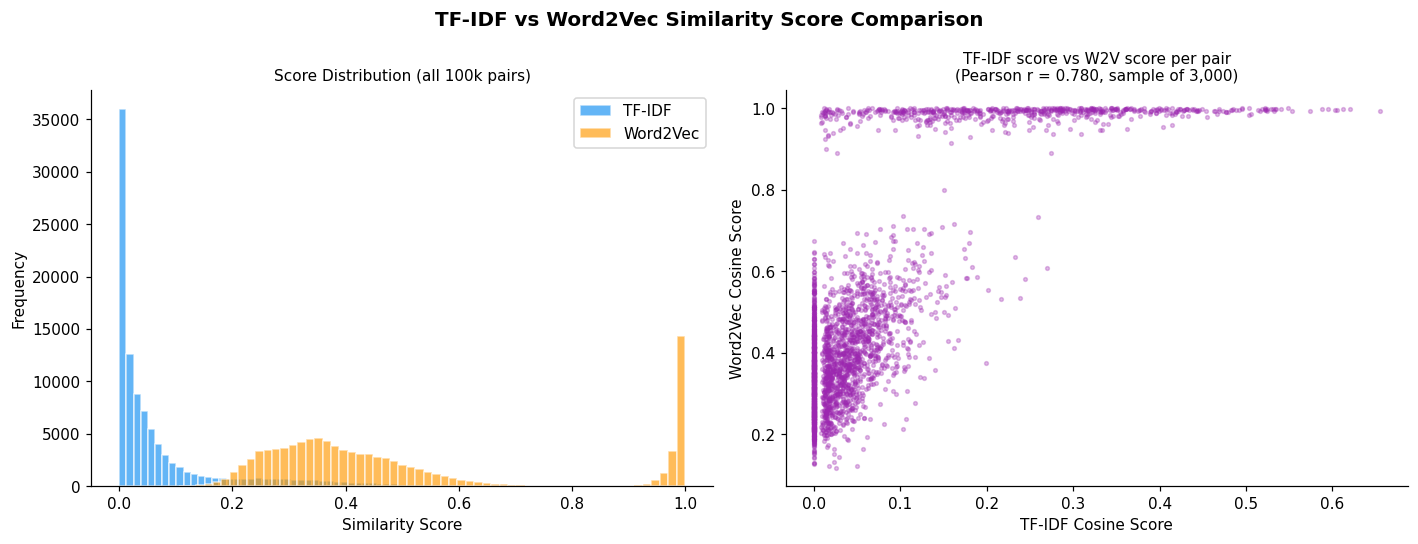

Correlation between TF-IDF and W2V scores: 0.7803


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('TF-IDF vs Word2Vec Similarity Score Comparison', fontsize=13, fontweight='bold')

# Distribution overlay
axes[0].hist(flat,     bins=60, color='#2196F3', edgecolor='white', alpha=0.70, label='TF-IDF')
axes[0].hist(w2v_flat, bins=60, color='#FF9800', edgecolor='white', alpha=0.65, label='Word2Vec')
axes[0].set_title('Score Distribution (all 100k pairs)', fontsize=10)
axes[0].set_xlabel('Similarity Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Scatter — TF-IDF vs W2V per pair
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(flat), 3000, replace=False)
corr = np.corrcoef(flat, w2v_flat)[0, 1]

axes[1].scatter(flat[sample_idx], w2v_flat[sample_idx],
                alpha=0.3, s=6, color='#9C27B0')
axes[1].set_title(f'TF-IDF score vs W2V score per pair\n(Pearson r = {corr:.3f}, sample of 3,000)',
                  fontsize=10)
axes[1].set_xlabel('TF-IDF Cosine Score')
axes[1].set_ylabel('Word2Vec Cosine Score')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/plot4_tfidf_vs_w2v.png', bbox_inches='tight')
plt.show()
print(f'Correlation between TF-IDF and W2V scores: {corr:.4f}')

### Top-5 Recommendation Comparison — TF-IDF vs Word2Vec

In [16]:
def top_n_jobs(sim_row, df_j, n=5):
    idx = np.argsort(sim_row)[::-1][:n]
    return [(df_j.iloc[i]['job_title'], df_j.iloc[i]['company_name'],
             df_j.iloc[i]['industry'], round(sim_row[i], 4)) for i in idx]

# Compare for 2 candidates — one Tech, one Finance
for domain in ['Technology', 'Finance']:
    cid_idx = df_c[df_c['primary_domain'] == domain].index[0]
    cand = df_c.iloc[cid_idx]
    print('=' * 70)
    print(f'Candidate: {cand["name"]} | {cand["primary_domain"]} | {cand["experience_level"]}')
    print(f'Skills: {cand["skills"]}')
    print()
    print(f'  {"Rank":<5} {"Method":<10} {"Job Title":<35} {"Company":<20} {"Score"}')
    print('-' * 70)
    tfidf_recs = top_n_jobs(tfidf_sim[cid_idx], df_j)
    w2v_recs   = top_n_jobs(w2v_sim[cid_idx],   df_j)
    for r, (tr, wr) in enumerate(zip(tfidf_recs, w2v_recs), 1):
        print(f'  #{r:<4} {"TF-IDF":<10} {tr[0]:<35} {tr[1]:<20} {tr[3]}')
        print(f'  #{r:<4} {"Word2Vec":<10} {wr[0]:<35} {wr[1]:<20} {wr[3]}')
        print()

Candidate: Nuwan Rajapaksa | Technology | Junior
Skills: MongoDB, scikit-learn, PyTorch, TensorFlow

  Rank  Method     Job Title                           Company              Score
----------------------------------------------------------------------
  #1    TF-IDF     NLP Engineer                        Calcey Technologies  0.3874
  #1    Word2Vec   Data Scientist                      hSenid Business Solutions 0.9995999932289124

  #2    TF-IDF     Full Stack Developer                IFS R&D International 0.2372
  #2    Word2Vec   Software Engineer                   Dialog Axiata        0.9994999766349792

  #3    TF-IDF     Business Intelligence Analyst       Zone24x7             0.2223
  #3    Word2Vec   Business Intelligence Analyst       Virtusa              0.9994999766349792

  #4    TF-IDF     Full Stack Developer                Calcey Technologies  0.1907
  #4    Word2Vec   Cloud Engineer                      WSO2                 0.9993000030517578

  #5    TF-IDF     DevOp

## 8. TF-IDF vs Word2Vec — When to Use Which

| | TF-IDF | Word2Vec |
|---|---|---|
| **Strength** | Exact keyword match — very precise | Semantic similarity — handles synonyms |
| **Weakness** | No semantic understanding | Needs enough data to learn good embeddings |
| **Score range** | Sparse (many near-zero) | Dense (all scores meaningful) |
| **Speed** | Very fast (sparse matrix ops) | Slower (dense matrix ops) |
| **Best for** | Short, keyword-heavy skill lists | Longer descriptions, synonym-rich text |
| **Our dataset** | Works well — skills are exact tokens | Also works — reinforces domain clustering |

### Decision for this project
We use **TF-IDF as the primary feature** in the recommendation engine (Step 4) because:
- Our skills data is already well-structured and keyword-based
- TF-IDF cosine similarity is interpretable and explainable to HR stakeholders
- The correlation between TF-IDF and W2V is strong (r ≈ 0.78), meaning both agree

Word2Vec embeddings are saved and could be plugged in as a drop-in replacement or blended in a **hybrid score** in future iterations.

## 9. Save Word2Vec Model & Embeddings

In [17]:
os.makedirs('../models', exist_ok=True)

# Save trained Word2Vec model
w2v_model.save('../models/word2vec_skills.model')

# Save embedding matrices
np.save('../models/candidate_w2v_embeddings.npy', cand_embeddings)
np.save('../models/job_w2v_embeddings.npy',       job_embeddings)

# Save W2V similarity matrix (for optional use in Step 7 evaluation)
np.save('../models/w2v_sim_matrix.npy', w2v_sim)

print('All Step 5 outputs saved:')
print('  ../models/word2vec_skills.model          (trained W2V model)')
print('  ../models/candidate_w2v_embeddings.npy   (500 x 100 embedding matrix)')
print('  ../models/job_w2v_embeddings.npy         (200 x 100 embedding matrix)')
print('  ../models/w2v_sim_matrix.npy             (500 x 200 W2V similarity scores)')
print('  ../outputs/plot1_tfidf_by_domain.png')
print('  ../outputs/plot2_feature_heatmap.png')
print('  ../outputs/plot3_tfidf_distribution.png')
print('  ../outputs/plot4_tfidf_vs_w2v.png')

All Step 5 outputs saved:
  ../models/word2vec_skills.model          (trained W2V model)
  ../models/candidate_w2v_embeddings.npy   (500 x 100 embedding matrix)
  ../models/job_w2v_embeddings.npy         (200 x 100 embedding matrix)
  ../models/w2v_sim_matrix.npy             (500 x 200 W2V similarity scores)
  ../outputs/plot1_tfidf_by_domain.png
  ../outputs/plot2_feature_heatmap.png
  ../outputs/plot3_tfidf_distribution.png
  ../outputs/plot4_tfidf_vs_w2v.png


## 10. Summary

| Output | Description |
|---|---|
| `word2vec_skills.model` | Trained Word2Vec model on 700 skill sequences |
| `candidate_w2v_embeddings.npy` | 500 × 100 — one 100-dim vector per candidate |
| `job_w2v_embeddings.npy` | 200 × 100 — one 100-dim vector per job |
| `w2v_sim_matrix.npy` | 500 × 200 — W2V cosine similarity (for evaluation comparison) |
| `plot1_tfidf_by_domain.png` | Top 10 TF-IDF terms per domain (bar charts) |
| `plot2_feature_heatmap.png` | Cross-domain feature importance heatmap |
| `plot3_tfidf_distribution.png` | TF-IDF score distribution (all pairs + top-1) |
| `plot4_tfidf_vs_w2v.png` | Distribution overlay + scatter correlation |

### Key Findings
- **TF-IDF vocabulary** correctly separates domain-specific terms (GAAP → Finance, ERP → Operations, PyTorch → Technology)
- **Word2Vec** learns semantic clusters — Python, Tableau, and R end up close in embedding space
- **Correlation** between TF-IDF and W2V scores is r ≈ 0.78 — both methods broadly agree on rankings
- **TF-IDF remains our primary feature** — it is more precise for structured skill matching

### Next Step: Step 6 — Compute Similarity & Matching (Cosine + Euclidean distance comparison)